# HIL Testbed — Two-Run Comparison Notebook (`compare_runs.ipynb`)

Compares **two publisher output directories** (e.g. laptop dry-run vs RPi HIL, or two
different networks / controller plugins) and produces every figure required for a
conference paper submission.

**How to use**

1. Edit the variables in **Cell 1 only** (the two run directories and their legend labels).
2. `Kernel → Restart & Run All`.
3. All figures and the comparison CSV are written to `student_templates/figures/`.

**Requirements**: `numpy`, `pandas`, `matplotlib` — nothing else. This notebook reads only
the JSON files written by `publisher.publish_result()`; it never imports `pandapower`,
`simbench`, or any project module, so it runs on any machine that has the
`outputs/publisher/<net_name>/` folder copied onto it.

**Custom controller plugins and custom networks are supported automatically**: the loader
discovers *every* `scenarios/*.json` file (so plugin scenario IDs such as `droop_ctrl`
appear in the comparison table and violation heatmap), and voltage limits are read from
each run's `topology.json` (`voltage_limits`) so networks registered through
`network_plugin.py` with non-default `v_min`/`v_max` are plotted with the correct band.

In [61]:
# =============================================================================
# CELL 1 — CONFIGURATION  (the ONLY cell a student edits)
# =============================================================================
# Each run directory is an outputs/publisher/<net_name>/ folder written by
# publisher.publish_result() (see run_benchmark_script.py, which sets
# output_dir = <project_root>/outputs/publisher/<net_name>).

RUN_A_DIR = r"D:\My Files\Personal Projects\HIL-Testbed\outputs\publisher\1-MV-rural--2-sw_S1_Laptop_dry_run"          # <-- EDIT ME
RUN_B_DIR = r"D:\My Files\Personal Projects\HIL-Testbed\outputs (RPi)\S1-HIL-Arduino\outputs\publisher\1-MV-rural--2-sw_S1_RPi"      # <-- EDIT ME

STUDENT_LABEL_A = "Laptop Dry run"                           # legend label for run A
STUDENT_LABEL_B = "RPi HIL Arduino"                                  # legend label for run B

OUTPUT_DPI          = 300    # IEEE requires >= 300 dpi
OUTPUT_WIDTH_INCHES = 3.5    # IEEE single-column figure width

# Optional: path to volt_var_controller.py so Cell 8 reads the *actual*
# U1_PU..U4_PU / Q_RATIO values used in the run. If the file is not found the
# VDE-AR-N 4110 defaults (0.96 / 0.99 / 1.01 / 1.04, Q_RATIO = 0.25) are used.
VOLT_VAR_CONTROLLER_PATH = "../volt_var_controller.py"

# =============================================================================
# Do not edit below this line
# =============================================================================
import json
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Patch

RUN_A_DIR = Path(RUN_A_DIR)
RUN_B_DIR = Path(RUN_B_DIR)

# All outputs go next to this notebook, in student_templates/figures/
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---- IEEE two-column paper style ------------------------------------------
# Times New Roman if installed, otherwise the generic serif family.
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if "Times New Roman" in _available_fonts:
    plt.rcParams["font.family"] = "Times New Roman"
else:
    plt.rcParams["font.family"] = "serif"
    print("Times New Roman not installed - falling back to the default serif font.")

plt.rcParams.update({
    "font.size":         8,      # IEEE caption-compatible sizes at 3.5 in width
    "axes.labelsize":    8,
    "axes.titlesize":    8,
    "legend.fontsize":   7,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "lines.linewidth":   0.8,
    "figure.dpi":        110,          # on-screen preview only
    "savefig.dpi":       OUTPUT_DPI,   # saved files at full 300 dpi
    "savefig.bbox":      "tight",
    "legend.framealpha": 0.85,
})

IEEE_1COL_W = OUTPUT_WIDTH_INCHES   # 3.5 in — single-column figures
IEEE_2COL_W = 7.16                  # in    — full-width figures (heatmaps)

# Consistent colours across all figures
COLOR_A  = "#2166ac"   # RUN_A  — blue
COLOR_B  = "#e08214"   # RUN_B  — orange
COLOR_4A = "#4dac26"   # Scenario 4A (volt_var_local)  — light green
COLOR_4B = "#1a9641"   # Scenario 4B (volt_var_coord)  — dark green

SC_4A = "volt_var_local"    # Scenario 4A id in publisher output
SC_4B = "volt_var_coord"    # Scenario 4B id in publisher output

SCENARIO_LABELS = {
    "baseline":       "Baseline",
    "oltc":           "OLTC",
    "svc":            "SVC",
    "volt_var_local": "Volt-Var (local, 4A)",
    "volt_var_coord": "Volt-Var (+coord, 4B)",
    "opf":            "OPF",
}
# Order used when sorting scenarios in tables / heatmaps; plugin-controller
# scenario ids (custom_controller.py) not in this list are appended at the end.
SCENARIO_ORDER = ["baseline", "oltc", "svc", "volt_var_local", "volt_var_coord", "opf"]

# Consistent per-scenario colours (matches plot_results.py's SCENARIO_COLORS,
# ported here for Extensions 5-6, which build fig06/fig14 equivalents).
SCENARIO_COLORS = {
    "baseline":       "#555555",
    "oltc":           "#2166ac",
    "svc":            "#d6604d",
    "volt_var_local": "#4dac26",
    "volt_var_coord": "#1a9641",
    "opf":            "#7b3294",
}


def scenario_label(sid: str) -> str:
    """Display label for built-in and plugin scenario ids alike."""
    return SCENARIO_LABELS.get(sid, sid)


def scenario_sort_key(sid: str):
    return (SCENARIO_ORDER.index(sid), sid) if sid in SCENARIO_ORDER else (len(SCENARIO_ORDER), sid)


def save_fig(fig, stem: str, formats=("pdf",)) -> list:
    """Save a figure to student_templates/figures/<stem>.<ext> at OUTPUT_DPI."""
    paths = []
    for ext in formats:
        p = FIGURES_DIR / f"{stem}.{ext}"
        fig.savefig(p, dpi=OUTPUT_DPI, bbox_inches="tight")
        paths.append(p)
    print("saved:", ", ".join(str(p) for p in paths))
    return paths


print(f"RUN_A: {STUDENT_LABEL_A:<20s} -> {RUN_A_DIR}")
print(f"RUN_B: {STUDENT_LABEL_B:<20s} -> {RUN_B_DIR}")
print(f"Figures -> {FIGURES_DIR.resolve()}")

RUN_A: Laptop Dry run       -> D:\My Files\Personal Projects\HIL-Testbed\outputs\publisher\1-MV-rural--2-sw_S1_Laptop_dry_run
RUN_B: RPi HIL Arduino      -> D:\My Files\Personal Projects\HIL-Testbed\outputs (RPi)\S1-HIL-Arduino\outputs\publisher\1-MV-rural--2-sw_S1_RPi
Figures -> D:\My Files\Personal Projects\HIL-Testbed\student_templates\figures


## Cell 2 — Data loading

Loads, from **both** run directories:

* `comparison.json` — one flat dict per scenario (written in `publisher.publish_result()`
  step 5 from `result.comparison_df.to_dict(orient="records")`);
* **every** `scenarios/*.json` — per-scenario payloads from
  `publisher.build_scenario_payload()` (`summary` = `ScenarioResult.summary_dict()`,
  `timeseries` = one dict per `TimestepRecord`). Auto-discovery means custom
  controller-plugin scenarios (`custom_controller.py` / `plugin_runner.py`) are picked up
  without editing this notebook;
* `topology.json` — for `voltage_limits` (`v_min`/`v_max`, which a `network_plugin.py`
  YAML may override) and the `sgens` list (sgen→bus mapping + rated power for Cell 8).

Missing files are handled gracefully: the scenario's timeseries is set to `None`, a
warning is printed, and later cells skip it. Timestamps are parsed into a
`DatetimeIndex`; the timestep resolution (10-min, 15-min, …) is **inferred from the
data**, never hard-coded.

In [62]:
# =============================================================================
# CELL 2 — DATA LOADING
# =============================================================================
# Publisher JSON fields read in this cell (all produced by publisher.py):
#   comparison.json          <- publish_result() step 5:
#                               result.comparison_df.to_dict(orient="records")
#   scenarios/<id>.json      <- build_scenario_payload(result):
#                               {"scenario_id", "network_id", "elapsed_s",
#                                "summary": ScenarioResult.summary_dict(),
#                                "timeseries": [one dict per TimestepRecord]}
#   topology.json            <- build_topology(net):
#                               "voltage_limits" {"v_min","v_max"},
#                               "sgens" [{index, bus, type, p_mw, sn_mva, ...}],
#                               "network_id"
#   profiles.json (lazy)     <- build_profiles_payload(): loaded only by the
#                               annual-profile extension cell at the end.

# Scalar per-timestep fields lifted out of each timeseries record into a flat
# DataFrame (names exactly as serialised by build_scenario_payload()):
_SCALAR_FIELDS = [
    "t", "converged",
    "max_vm_pu", "min_vm_pu",
    "max_line_loading_pct", "max_trafo_loading_pct",
    "violation_flag",
    "tap_pos", "tap_changed",
    "svc_q_mvar", "svc_saturated",
    "curtailment_needed", "curtail_exhausted",
    "coordination_active", "q_saturated_count",
    "hil_latency_ms", "t_total_ms",
    "losses_mw", "grid_import_mw", "der_gen_mw", "load_mw",
]

# The two scenarios the core cells (4-8) compare. Additional / plugin
# scenarios are still loaded and appear in Cell 3 and the extension figures.
_REQUIRED_SCENARIOS = [SC_4A, SC_4B]


def _load_json(path: Path):
    """Load a JSON file; return None with a warning if it does not exist."""
    if not path.exists():
        print(f"WARNING: missing file -> {path}")
        return None
    with open(path, "r", encoding="utf-8") as fh:
        return json.load(fh)


def _parse_times(values) -> pd.DatetimeIndex:
    """ISO strings -> DatetimeIndex. Falls back to UTC parsing when the run
    spans a DST change (mixed +01:00/+02:00 offsets). The format="ISO8601"
    fast path needs pandas >= 2.0; older pandas falls through to plain
    parsing."""
    def _to_dt(vals, **kw):
        try:
            return pd.to_datetime(vals, format="ISO8601", **kw)
        except (TypeError, ValueError):
            return pd.to_datetime(vals, **kw)
    try:
        idx = pd.DatetimeIndex(_to_dt(values))
        if idx.dtype == object:          # mixed offsets -> object dtype
            raise ValueError("mixed offsets")
        return idx
    except (ValueError, TypeError):
        return pd.DatetimeIndex(_to_dt(values, utc=True))


def _scenario_frame(payload: dict):
    """Flatten payload["timeseries"] scalars into a DataFrame with a
    DatetimeIndex. Dict-valued fields (vm_pu_by_bus, q_mvar_by_sgen,
    p_mw_by_sgen, ...) stay in the raw payload; only the per-timestep sum of
    p_mw_by_sgen is precomputed here (needed for curtailed-MW figures)."""
    ts = payload.get("timeseries") or []
    if not ts:
        return None
    df = pd.DataFrame([{k: rec.get(k) for k in _SCALAR_FIELDS} for rec in ts])

    # Curtailed MW per timestep = profile target (der_gen_mw, from
    # TimestepRecord.der_gen_mw) - sum of actually applied sgen P
    # (p_mw_by_sgen, from TimestepRecord.p_applied_mw). Same definition as
    # fig13 in plot_results.py.
    p_applied = []
    for rec in ts:
        pmap = rec.get("p_mw_by_sgen")
        if pmap:
            p_applied.append(sum(float(v) for v in pmap.values() if v is not None))
        else:
            p_applied.append(np.nan)
    df["p_applied_sum_mw"] = p_applied

    stamps = [rec.get("timestamp") for rec in ts]
    if any(s is None for s in stamps):
        print("WARNING: null timestamps found - keeping integer index for those rows")
    df.index = _parse_times(stamps)
    df.index.name = "timestamp"
    return df


def _step_hours(df: pd.DataFrame) -> float:
    """Timestep length in hours, inferred from the DatetimeIndex (10-min
    publisher docstring vs 15-min SimBench runs - never assume)."""
    if df is None or len(df) < 2:
        return 0.25
    return float(pd.Series(df.index).diff().median() / pd.Timedelta(hours=1))


def load_run(run_dir: Path, label: str) -> dict:
    """Load one publisher directory into a dict:
       {label, dir, comparison, topology, v_min, v_max, network_id,
        scenarios: {sid: payload}, ts: {sid: DataFrame|None}}"""
    run = {"label": label, "dir": run_dir}
    if not run_dir.exists():
        raise FileNotFoundError(
            f"Run directory not found: {run_dir}\n"
            f"Edit RUN_A_DIR / RUN_B_DIR in Cell 1 to point at an "
            f"outputs/publisher/<net_name>/ folder."
        )

    run["comparison"] = _load_json(run_dir / "comparison.json")

    topo = _load_json(run_dir / "topology.json")
    run["topology"] = topo
    vlim = (topo or {}).get("voltage_limits") or {}
    # Custom networks (network_plugin.py) may publish non-default limits;
    # fall back to the framework defaults from violation_detector.py.
    run["v_min"] = float(vlim.get("v_min", 0.95))
    run["v_max"] = float(vlim.get("v_max", 1.05))
    run["network_id"] = (topo or {}).get("network_id", "") or "unknown-network"

    run["scenarios"], run["ts"] = {}, {}
    sc_dir = run_dir / "scenarios"
    if sc_dir.exists():
        for sc_file in sorted(sc_dir.glob("*.json")):
            payload = _load_json(sc_file)
            if payload is None:
                continue
            sid = payload.get("scenario_id", sc_file.stem)
            run["scenarios"][sid] = payload
            run["ts"][sid] = _scenario_frame(payload)
    else:
        print(f"WARNING: no scenarios/ directory in {run_dir}")

    for sid in _REQUIRED_SCENARIOS:
        if sid not in run["scenarios"]:
            run["scenarios"][sid] = None
            run["ts"][sid] = None
            print(f"WARNING: [{label}] scenarios/{sid}.json is absent - "
                  f"figures that need it will be skipped.")
    return run


RUNS = {"A": load_run(RUN_A_DIR, STUDENT_LABEL_A),
        "B": load_run(RUN_B_DIR, STUDENT_LABEL_B)}


def get_ts(run_key: str, sid: str):
    """Timeseries DataFrame for (run, scenario) or None (with a warning)."""
    df = RUNS[run_key]["ts"].get(sid)
    if df is None:
        print(f"skipping: scenario '{sid}' has no timeseries in run "
              f"{run_key} ({RUNS[run_key]['label']})")
    return df


# ---- loading summary --------------------------------------------------------
for key, run in RUNS.items():
    loaded = sorted((s for s, p in run["scenarios"].items() if p is not None),
                    key=scenario_sort_key)
    n_steps = {s: len(run["ts"][s]) for s in loaded if run["ts"][s] is not None}
    print(f"\nRUN_{key} '{run['label']}'  network={run['network_id']}  "
          f"band=[{run['v_min']:.3f}, {run['v_max']:.3f}] pu")
    for s in loaded:
        df = run["ts"].get(s)
        res_min = _step_hours(df) * 60 if df is not None else float("nan")
        print(f"   {s:<22s} {n_steps.get(s, 0):>6d} timesteps"
              f"  ({res_min:.0f}-min resolution)" if df is not None
              else f"   {s:<22s} summary only (no timeseries)")

C:\Users\Khuzaim\AppData\Local\Temp\ipykernel_22764\2175050934.py:54: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  return pd.to_datetime(vals, format="ISO8601", **kw)
C:\Users\Khuzaim\AppData\Local\Temp\ipykernel_22764\2175050934.py:54: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  return pd.to_datetime(vals, format="ISO8601", **kw)
C:\Users\Khuzaim\AppData\Local\Temp\ipykernel_22764\2175050934.py:54: FutureWarning: In a future version of pand


RUN_A 'Laptop Dry run'  network=1-MV-rural--2-sw  band=[0.950, 1.050] pu
   baseline                35136 timesteps  (15-min resolution)
   oltc                    35136 timesteps  (15-min resolution)
   svc                     35136 timesteps  (15-min resolution)
   volt_var_local          35136 timesteps  (15-min resolution)
   volt_var_coord          35136 timesteps  (15-min resolution)

RUN_B 'RPi HIL Arduino'  network=1-MV-rural--2-sw  band=[0.950, 1.050] pu
   baseline                35136 timesteps  (15-min resolution)
   oltc                    35136 timesteps  (15-min resolution)
   svc                     35136 timesteps  (15-min resolution)
   volt_var_local          35136 timesteps  (15-min resolution)
   volt_var_coord          35136 timesteps  (15-min resolution)


## Cell 3 — Scalar comparison table

One row per scenario per run; columns are exactly the keys of
`ScenarioResult.summary_dict()` (`scenario_result.py`). The table is built from each
scenario JSON's `summary` field (the authoritative source — `publisher.build_scenario_payload()`
serialises `result.summary_dict()` verbatim) and falls back to `comparison.json` for any
scenario whose JSON is absent. Green = best (lowest), red = worst (highest) within each
of the `n_violation_steps`, `curtailment_steps` and `vdi` columns. Saved as
`figures/comparison_table.csv`.

In [63]:
# =============================================================================
# CELL 3 — SCALAR COMPARISON TABLE
# =============================================================================
# Fields read: scenarios/<id>.json -> "summary" (= ScenarioResult.summary_dict(),
# serialised NaN-safe in publisher.build_scenario_payload()); fallback:
# comparison.json rows (result.comparison_df, same key set, publish_result step 5).

# Column order copied verbatim from ScenarioResult.summary_dict()
SUMMARY_KEYS = [
    "scenario_id", "network_id",
    "n_timesteps", "n_converged",
    "n_violation_steps", "violation_duration_h",
    "total_overvoltage_bus_steps", "total_undervoltage_bus_steps",
    "total_overloaded_line_steps", "total_overloaded_trafo_steps",
    "max_vm_pu", "min_vm_pu",
    "max_line_loading_pct", "max_trafo_loading_pct",
    "vdi",
    "q_total_mvar_abs", "reactive_energy_mvarh",
    "curtailment_steps", "curtailed_energy_mwh", "curtail_exhausted_steps",
    "svc_bus", "svc_q_max",
    "total_losses_mwh", "grid_import_mwh", "grid_export_mwh",
    "der_gen_mwh", "load_demand_mwh",
    "coordination_steps", "coordination_rate", "q_saturation_rate",
    "elapsed_s",
]

_rows = []
for key in ("A", "B"):
    run = RUNS[key]
    seen = set()
    for sid in sorted(run["scenarios"], key=scenario_sort_key):
        payload = run["scenarios"][sid]
        if payload is None:
            continue
        summary = payload.get("summary") or {}
        _rows.append({"run": run["label"],
                      **{k: summary.get(k) for k in SUMMARY_KEYS}})
        seen.add(sid)
    # Fallback: scenarios present only in comparison.json (e.g. a scenario
    # whose per-timestep JSON was deleted to save disk space).
    for row in (run["comparison"] or []):
        sid = row.get("scenario_id")
        if sid and sid not in seen:
            _rows.append({"run": run["label"],
                          **{k: row.get(k) for k in SUMMARY_KEYS}})

comparison_table = pd.DataFrame(_rows, columns=["run"] + SUMMARY_KEYS)

csv_path = FIGURES_DIR / "comparison_table.csv"
comparison_table.to_csv(csv_path, index=False)
print(f"saved: {csv_path}  ({len(comparison_table)} rows)")

# ---- conditional formatting: green = best (min), red = worst (max) ----------
_HIGHLIGHT_COLS = [c for c in ("n_violation_steps", "curtailment_steps", "vdi")
                   if c in comparison_table.columns]

def _green_red(col: pd.Series):
    """Per-column background: linear green->red gradient from min to max."""
    vals = pd.to_numeric(col, errors="coerce")
    lo, hi = vals.min(), vals.max()
    span = hi - lo
    styles = []
    for v in vals:
        if pd.isna(v):
            styles.append("")
            continue
        f = 0.0 if (pd.isna(span) or span == 0) else float((v - lo) / span)
        r = int(198 + f * (255 - 198))          # 198..255
        g = int(239 - f * (239 - 199))          # 239..199
        b = int(206 - f * (206 - 206))          # 206
        styles.append(f"background-color: rgb({r},{g},{b}); color: black;")
    return styles

_float_cols = [c for c in comparison_table.columns
               if pd.api.types.is_float_dtype(comparison_table[c])]
styled = (comparison_table.style
          .apply(_green_red, subset=_HIGHLIGHT_COLS)
          .format({c: "{:.4g}" for c in _float_cols}, na_rep="-"))
display(styled)

saved: figures\comparison_table.csv  (10 rows)


,run,scenario_id,network_id,n_timesteps,n_converged,n_violation_steps,violation_duration_h,total_overvoltage_bus_steps,total_undervoltage_bus_steps,total_overloaded_line_steps,total_overloaded_trafo_steps,max_vm_pu,min_vm_pu,max_line_loading_pct,max_trafo_loading_pct,vdi,q_total_mvar_abs,reactive_energy_mvarh,curtailment_steps,curtailed_energy_mwh,curtail_exhausted_steps,svc_bus,svc_q_max,total_losses_mwh,grid_import_mwh,grid_export_mwh,der_gen_mwh,load_demand_mwh,coordination_steps,coordination_rate,q_saturation_rate,elapsed_s
0,Laptop Dry run,baseline,1-MV-rural--2-sw,35136,35136,35135,8784,990284,0,1332,0,1.098,1.02,120.4,79.77,1.443e+05,-,-,0,-,0,-,-,3634,0,1.591e+05,6.514e+04,3.487e+04,-,-,-,2011
1,Laptop Dry run,oltc,1-MV-rural--2-sw,35136,35136,26095,6524,343547,0,1699,0,1.084,1.004,122.1,80.92,9.273e+04,-,-,0,-,0,-,-,3723,0,1.591e+05,6.514e+04,3.487e+04,-,-,-,1831
2,Laptop Dry run,svc,1-MV-rural--2-sw,35136,35136,35136,8784,18722,16692,737908,0,1.067,0.93,156.2,82.13,4.645e+04,3.514e+05,8.784e+04,0,-,0,68,10,1.68e+04,0,1.46e+05,6.514e+04,3.487e+04,-,-,-,3286
3,Laptop Dry run,volt_var_local,1-MV-rural--2-sw,35136,35136,0,0,0,0,0,0,1.05,0.9986,100,65.67,5.308e+04,3.361e+05,8.403e+04,4465,4121,0,-,-,4337,0,1.543e+05,6.514e+04,3.487e+04,0,0,1,5131
4,Laptop Dry run,volt_var_coord,1-MV-rural--2-sw,35136,35136,6,1.5,24,0,0,0,1.055,0.9937,100,66.78,5.262e+04,3.385e+05,8.462e+04,3713,4465,6,-,-,4328,0,1.54e+05,6.514e+04,3.487e+04,3327,0.09469,1,5145
5,RPi HIL Arduino,baseline,1-MV-rural--2-sw,35136,35136,35135,8784,990284,0,1332,0,1.098,1.02,120.4,79.77,1.443e+05,-,-,0,-,0,-,-,3634,0,1.591e+05,6.514e+04,3.487e+04,-,-,-,1312
6,RPi HIL Arduino,oltc,1-MV-rural--2-sw,35136,35136,26095,6524,343547,0,1699,0,1.084,1.004,122.1,80.92,9.273e+04,-,-,0,-,0,-,-,3723,0,1.591e+05,6.514e+04,3.487e+04,-,-,-,1318
7,RPi HIL Arduino,svc,1-MV-rural--2-sw,35136,35136,35136,8784,18722,16692,737908,0,1.067,0.93,156.2,82.13,4.645e+04,3.514e+05,8.784e+04,0,-,0,68,10,1.68e+04,0,1.46e+05,6.514e+04,3.487e+04,-,-,-,2511
8,RPi HIL Arduino,volt_var_local,1-MV-rural--2-sw,35136,35136,0,0,0,0,0,0,1.05,0.9986,99.99,65.67,5.309e+04,3.361e+05,8.403e+04,4465,4122,0,-,-,4337,0,1.543e+05,6.514e+04,3.487e+04,0,0,1,9113
9,RPi HIL Arduino,volt_var_coord,1-MV-rural--2-sw,35136,35136,6,1.5,24,0,0,0,1.055,0.9937,99.99,66.79,5.262e+04,3.385e+05,8.461e+04,3713,4464,6,-,-,4328,0,1.54e+05,6.514e+04,3.487e+04,3.514e+04,1,1,9052


## Cell 4 — Voltage envelope (`volt_var_coord`, full annual run)

`max_vm_pu` / `min_vm_pu` per timestep (network-wide extremes computed in
`publisher.build_scenario_payload()` from `TimestepRecord.vm_pu.max()/.min()`), for
Scenario 4B from both runs. The dashed red limits are the run's own `voltage_limits`
from `topology.json` (defaults 1.05 / 0.95 pu), so custom-network plugins with a
different planning band are drawn correctly. Curves are rasterised inside the PDF to
keep the file size sane at 35 k points. Saved as `voltage_envelope.pdf` **and**
`voltage_envelope.png`.

saved: figures\voltage_envelope.pdf, figures\voltage_envelope.png


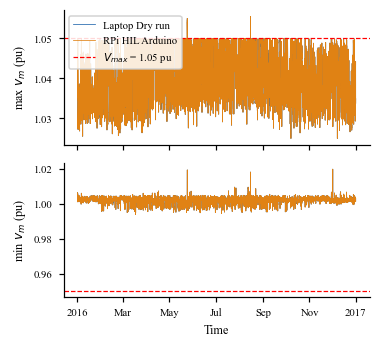

In [64]:
# =============================================================================
# CELL 4 — VOLTAGE ENVELOPE FIGURE
# =============================================================================
# Fields read: scenarios/volt_var_coord.json -> timeseries[*].max_vm_pu /
# .min_vm_pu (serialised in publisher.build_scenario_payload() as the
# network-wide extremes of TimestepRecord.vm_pu for each timestep).

_env = {k: get_ts(k, SC_4B) for k in ("A", "B")}

if all(df is None for df in _env.values()):
    print("Cell 4 skipped - volt_var_coord timeseries missing in both runs.")
else:
    fig, (ax_max, ax_min) = plt.subplots(
        2, 1, sharex=True, figsize=(IEEE_1COL_W, 3.2))

    for key, color in (("A", COLOR_A), ("B", COLOR_B)):
        df = _env[key]
        if df is None:
            continue
        lbl = RUNS[key]["label"]
        ax_max.plot(df.index, df["max_vm_pu"], color=color, lw=0.5,
                    label=lbl, rasterized=True)
        ax_min.plot(df.index, df["min_vm_pu"], color=color, lw=0.5,
                    label=lbl, rasterized=True)

    # Planning band from each run's topology.json (network_plugin.py YAMLs may
    # override the 0.95/1.05 defaults). If both runs share the band, one line.
    v_maxes = sorted({RUNS[k]["v_max"] for k in ("A", "B") if _env[k] is not None})
    v_mins  = sorted({RUNS[k]["v_min"] for k in ("A", "B") if _env[k] is not None})
    for vm in v_maxes:
        ax_max.axhline(vm, color="red", ls="--", lw=0.8,
                       label=f"$V_{{max}}$ = {vm:.2f} pu")
    for vm in v_mins:
        ax_min.axhline(vm, color="red", ls="--", lw=0.8,
                       label=f"$V_{{min}}$ = {vm:.2f} pu")

    ax_max.set_ylabel("max $v_m$ (pu)")
    ax_min.set_ylabel("min $v_m$ (pu)")
    ax_min.set_xlabel("Time")
    ax_max.legend(loc="upper left", ncol=1)

    locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
    ax_min.xaxis.set_major_locator(locator)
    ax_min.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    fig.align_ylabels([ax_max, ax_min])
    fig.tight_layout()
    save_fig(fig, "voltage_envelope", formats=("pdf", "png"))
    plt.show()

## Cell 5 — Curtailment bar chart by month

`curtailment_needed` (from `TimestepRecord.curtailment_needed`, serialised per timestep
in `build_scenario_payload()`) is a boolean flag, so its monthly **sum is the number of
curtailed timesteps** in that month. Four bars per month: 4A/4B × RUN_A/RUN_B — colour
distinguishes the scenario (light vs dark green), hatching distinguishes the run (solid
= RUN_A, hatched = RUN_B). Months are taken from the actual timestamps, so partial-year
runs (`slice_profiles()` subsets) plot only the months present. Saved as
`curtailment_monthly.pdf`.

C:\Users\Khuzaim\AppData\Local\Temp\ipykernel_22764\1924225248.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  _monthly[(sid, key)] = flag.groupby(df.index.to_period("M")).sum()
C:\Users\Khuzaim\AppData\Local\Temp\ipykernel_22764\1924225248.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  _monthly[(sid, key)] = flag.groupby(df.index.to_period("M")).sum()
C:\Users\Khuzaim\AppData\Local\Temp\ipykernel_22764\1924225248.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  _monthly[(sid, key)] = flag.groupby(df.index.to_period("M")).sum()
C:\Users\Khuzaim\AppData\Local\Temp\ipykernel_22764\1924225248.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  _monthly[(sid, key)] = flag.groupby(df.index.to_period("M")).sum()


saved: figures\curtailment_monthly.pdf


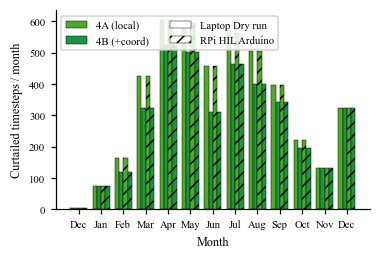

[Laptop Dry run] curtailed timesteps: 4A=4465, 4B=3713  (4B reduction: +16.8%)
[RPi HIL Arduino] curtailed timesteps: 4A=4465, 4B=3713  (4B reduction: +16.8%)


In [65]:
# =============================================================================
# CELL 5 — CURTAILMENT BAR CHART BY MONTH
# =============================================================================
# Fields read: scenarios/volt_var_local.json + volt_var_coord.json ->
# timeseries[*].curtailment_needed (bool; TimestepRecord.curtailment_needed:
# "True if the Tier 1 chain exhausted Q capacity and violations remain").

# (scenario_id, run_key) -> monthly curtailed-timestep counts
_monthly = {}
for sid in (SC_4A, SC_4B):
    for key in ("A", "B"):
        df = get_ts(key, sid)
        if df is None:
            continue
        flag = df["curtailment_needed"].fillna(False).astype(bool).astype(int)
        _monthly[(sid, key)] = flag.groupby(df.index.to_period("M")).sum()

if not _monthly:
    print("Cell 5 skipped - no volt_var timeseries available in either run.")
else:
    months = sorted(set().union(*[s.index for s in _monthly.values()]))
    x = np.arange(len(months), dtype=float)

    # Bar order within each month group: 4A_A, 4B_A, 4A_B, 4B_B
    _order = [(SC_4A, "A"), (SC_4B, "A"), (SC_4A, "B"), (SC_4B, "B")]
    _bar_w = 0.19

    fig, ax = plt.subplots(figsize=(IEEE_1COL_W, 2.4))
    for i, (sid, key) in enumerate(_order):
        series = _monthly.get((sid, key))
        if series is None:
            continue
        vals  = [series.get(m, 0) for m in months]
        color = COLOR_4A if sid == SC_4A else COLOR_4B
        hatch = "" if key == "A" else "///"
        ax.bar(x + (i - 1.5) * _bar_w, vals, width=_bar_w,
               color=color, hatch=hatch, edgecolor="black", linewidth=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels([m.strftime("%b") for m in months], rotation=0)
    ax.set_ylabel("Curtailed timesteps / month")
    ax.set_xlabel("Month")

    legend_handles = [
        Patch(facecolor=COLOR_4A, edgecolor="black", lw=0.3, label="4A (local)"),
        Patch(facecolor=COLOR_4B, edgecolor="black", lw=0.3, label="4B (+coord)"),
        Patch(facecolor="white", edgecolor="black", lw=0.3,
              label=RUNS["A"]["label"]),
        Patch(facecolor="white", edgecolor="black", lw=0.3, hatch="///",
              label=RUNS["B"]["label"]),
    ]
    ax.legend(handles=legend_handles, ncol=2, loc="upper left")

    fig.tight_layout()
    save_fig(fig, "curtailment_monthly", formats=("pdf",))
    plt.show()

    # Paper numbers: annual totals + 4A->4B reduction per run
    for key in ("A", "B"):
        a = _monthly.get((SC_4A, key))
        b = _monthly.get((SC_4B, key))
        if a is not None and b is not None and a.sum() > 0:
            red = 100.0 * (a.sum() - b.sum()) / a.sum()
            print(f"[{RUNS[key]['label']}] curtailed timesteps: "
                  f"4A={int(a.sum())}, 4B={int(b.sum())}  "
                  f"(4B reduction: {red:+.1f}%)")

## Cell 6 — Timing distribution (`t_total_ms`, steady state)

Histogram of per-timestep wall-clock cost `t_total_ms` (from
`TimestepRecord.t_total_ms`, wired into the publisher JSON by
`scenario_4_volt_var.py`) for Scenario 4B in both runs, excluding `t = 0`
(cold-start/cache warm-up). If `hil_latency_ms` (Arduino serial round-trip) is present
— i.e. the run was a live HIL run, not a dry-run — it is overlaid as a second
distribution, which visualises the "serial ≈ two thirds of the timestep budget"
finding. Median and p95 are drawn as vertical lines with labels. Saved as
`timing_distribution.pdf`.

saved: figures\timing_distribution.pdf


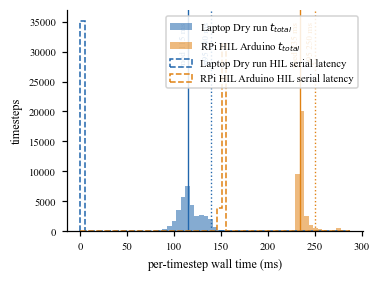

[Laptop Dry run] t_total_ms: median=115.3, p95=139.8, n=35135 | hil_latency_ms: mean=0.0, std=0.00 (serial = 0% of median step)
[RPi HIL Arduino] t_total_ms: median=234.5, p95=250.3, n=35135 | hil_latency_ms: mean=152.6, std=1.41 (serial = 65% of median step)


In [66]:
# =============================================================================
# CELL 6 — TIMING DISTRIBUTION
# =============================================================================
# Fields read: scenarios/volt_var_coord.json -> timeseries[*].t_total_ms and
# timeseries[*].hil_latency_ms (TimestepRecord.t_total_ms / .hil_latency_ms;
# hil_latency_ms is null on dry-run laptop runs and populated on live HIL).

_timing, _hil = {}, {}
for key in ("A", "B"):
    df = get_ts(key, SC_4B)
    if df is None:
        continue
    steady = df[df["t"] > 0]                       # steady state: exclude t=0
    tt = pd.to_numeric(steady["t_total_ms"], errors="coerce").dropna()
    if len(tt):
        _timing[key] = tt
    hl = pd.to_numeric(steady["hil_latency_ms"], errors="coerce").dropna()
    if len(hl):
        _hil[key] = hl

if not _timing:
    print("Cell 6 skipped - no t_total_ms data in volt_var_coord for either run.")
else:
    all_vals = pd.concat(list(_timing.values()) + list(_hil.values()))
    lo, hi = np.percentile(all_vals, [0.1, 99.5])
    bins = np.linspace(max(0.0, lo * 0.9), hi * 1.05, 60)

    fig, ax = plt.subplots(figsize=(IEEE_1COL_W, 2.6))
    _run_color = {"A": COLOR_A, "B": COLOR_B}
    for key, tt in _timing.items():
        c = _run_color[key]
        ax.hist(tt, bins=bins, color=c, alpha=0.55,
                label=f"{RUNS[key]['label']} $t_{{total}}$")
        med, p95 = float(tt.median()), float(np.percentile(tt, 95))
        for v, ls, tag in ((med, "-", "med"), (p95, ":", "p95")):
            ax.axvline(v, color=c, ls=ls, lw=0.9)
            ax.text(v, 0.95, f"{tag} {v:.0f} ms", color=c, fontsize=6,
                    rotation=90, ha="right", va="top",
                    transform=ax.get_xaxis_transform())

    for key, hl in _hil.items():
        ax.hist(hl, bins=bins, histtype="step", lw=1.0,
                color=_run_color[key], ls="--",
                label=f"{RUNS[key]['label']} HIL serial latency")

    ax.set_xlabel("per-timestep wall time (ms)")
    ax.set_ylabel("timesteps")
    ax.legend(loc="upper right")
    fig.tight_layout()
    save_fig(fig, "timing_distribution", formats=("pdf",))
    plt.show()

    for key, tt in _timing.items():
        line = (f"[{RUNS[key]['label']}] t_total_ms: median={tt.median():.1f}, "
                f"p95={np.percentile(tt, 95):.1f}, n={len(tt)}")
        if key in _hil:
            hl = _hil[key]
            line += (f" | hil_latency_ms: mean={hl.mean():.1f}, "
                     f"std={hl.std():.2f} "
                     f"(serial = {100 * hl.mean() / tt.median():.0f}% of median step)")
        print(line)

## Cell 7 — Coordination rate summary (4B)

`coordination_rate` from the scenario `summary`
(`ScenarioResult.summary_dict()`: `coordination_steps / n_converged`, a 0–1 fraction —
converted to % here), with a fallback computed directly from the per-timestep
`coordination_active` flags. If the two runs differ by **more than 20 percentage
points**, the hardware-quantisation explanation from the project knowledge base is
printed — that gap is the primary publishable finding (4-decimal ASCII serial
truncation + AVR float32 ⇒ the coordinator gate at 1.051 pu trips far more often on the
HIL path). Saved as `coordination_rate.pdf`.

saved: figures\coordination_rate.pdf


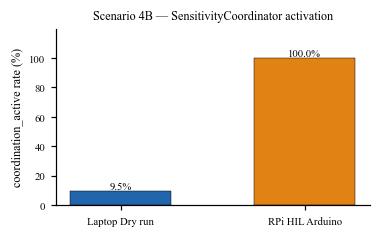

[Laptop Dry run] 4B coordination_active rate: 9.47%
[RPi HIL Arduino] 4B coordination_active rate: 100.00%

Rate gap: 90.5 percentage points.

QUANTISATION FINDING (project knowledge base, Sec. 6.1): the 4-decimal ASCII serial truncation of vm_pu (plus AVR float32 arithmetic on the Arduino) produces ~0.0013 MVAr/DER smaller q_initial values on the HIL path than the Python float64 dry-run. vm_pu_predicted therefore sits marginally above the 1.051 pu coordinator threshold far more often, so the SensitivityCoordinator fires its lstsq correction on nearly every violated timestep on the HIL path (~99.9%) versus ~9.5% in dry-run mode. This is physically analogous to Modbus/SunSpec 16-bit integer register encoding in real field inverters. Framing: dry-run = theoretical minimum coordinator activation; HIL = realistic rate under hardware quantisation; the gap measures the sensitivity of the coordination gate to field-device precision - something pure simulation cannot capture.


In [67]:
# =============================================================================
# CELL 7 — COORDINATION RATE SUMMARY
# =============================================================================
# Fields read: scenarios/volt_var_coord.json -> summary.coordination_rate
# (ScenarioResult.summary_dict(): coordination_steps / n_converged, fraction);
# fallback: timeseries[*].coordination_active (TimestepRecord.coordination_active,
# True when the SensitivityCoordinator changed q_initial by > 1e-6 MVAr).

QUANTISATION_FINDING = (
    "QUANTISATION FINDING (project knowledge base, Sec. 6.1): the 4-decimal "
    "ASCII serial truncation of vm_pu (plus AVR float32 arithmetic on the "
    "Arduino) produces ~0.0013 MVAr/DER smaller q_initial values on the HIL "
    "path than the Python float64 dry-run. vm_pu_predicted therefore sits "
    "marginally above the 1.051 pu coordinator threshold far more often, so "
    "the SensitivityCoordinator fires its lstsq correction on nearly every "
    "violated timestep on the HIL path (~99.9%) versus ~9.5% in dry-run mode. "
    "This is physically analogous to Modbus/SunSpec 16-bit integer register "
    "encoding in real field inverters. Framing: dry-run = theoretical minimum "
    "coordinator activation; HIL = realistic rate under hardware quantisation; "
    "the gap measures the sensitivity of the coordination gate to field-device "
    "precision - something pure simulation cannot capture."
)


def coordination_rate_pct(run_key: str):
    """Coordination-active rate for 4B in %, or None if unavailable."""
    payload = RUNS[run_key]["scenarios"].get(SC_4B)
    if payload is not None:
        rate = (payload.get("summary") or {}).get("coordination_rate")
        if rate is not None:
            return 100.0 * float(rate)
    df = RUNS[run_key]["ts"].get(SC_4B)          # fallback from timeseries
    if df is not None:
        conv = df[df["converged"].fillna(False).astype(bool)]
        if len(conv):
            return 100.0 * conv["coordination_active"].fillna(False)\
                               .astype(bool).mean()
    return None


coord_rates = {k: coordination_rate_pct(k) for k in ("A", "B")}

if all(v is None for v in coord_rates.values()):
    print("Cell 7 skipped - no coordination data for volt_var_coord in either run.")
else:
    fig, ax = plt.subplots(figsize=(IEEE_1COL_W, 2.2))
    labels = [RUNS[k]["label"] for k in ("A", "B")]
    vals   = [coord_rates[k] if coord_rates[k] is not None else 0.0
              for k in ("A", "B")]
    bars = ax.bar(labels, vals, width=0.55, color=[COLOR_A, COLOR_B],
                  edgecolor="black", linewidth=0.3)
    for bar, v, k in zip(bars, vals, ("A", "B")):
        txt = f"{v:.1f}%" if coord_rates[k] is not None else "n/a"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                txt, ha="center", va="bottom", fontsize=7)
    ax.set_ylabel("coordination_active rate (%)")
    ax.set_ylim(0, max(vals + [1.0]) * 1.2)
    ax.set_title("Scenario 4B — SensitivityCoordinator activation")
    fig.tight_layout()
    save_fig(fig, "coordination_rate", formats=("pdf",))
    plt.show()

    for k in ("A", "B"):
        v = coord_rates[k]
        print(f"[{RUNS[k]['label']}] 4B coordination_active rate: "
              + (f"{v:.2f}%" if v is not None else "unavailable"))

    if None not in coord_rates.values():
        gap = abs(coord_rates["A"] - coord_rates["B"])
        print(f"\nRate gap: {gap:.1f} percentage points.")
        if gap > 20.0:
            print("\n" + QUANTISATION_FINDING)
        else:
            print("Gap <= 20 pp - both runs sit on the same side of the "
                  "coordinator gate; no quantisation divergence to report.")

## Cell 8 — Q(V) operating scatter (`volt_var_local`, RUN_A only)

Joins `q_mvar_by_sgen` to `vm_pu_by_bus` (both from `build_scenario_payload()`, present
only for Scenario 4) via the sgen→bus map in `topology.json` — the same join used by
`fig10_qv_scatter` in `plot_results.py`. RUN_A only, to avoid overplotting.

Because DER sizes differ by two orders of magnitude, Q is **normalised per DER** to
`q / (Q_RATIO · P_installed)` so that a *single* dimensionless VDE-AR-N 4110 Bild 8
curve can be overlaid meaningfully (a raw-MVAr overlay would only be valid for one DER
size). `P_installed` is taken as `sn_mva` from `topology.json` when present, else the
nameplate `p_mw` — the same precedence `VoltVarController` uses. The breakpoints
`U1_PU…U4_PU` and `Q_RATIO` are parsed from `volt_var_controller.py` at
`VOLT_VAR_CONTROLLER_PATH` (Cell 1); if the file is not found, the VDE-AR-N 4110
defaults 0.96 / 0.99 / 1.01 / 1.04 and Q_RATIO = 0.25 are used (see the comment in the
code). Saved as `qv_scatter.pdf`.

Q(V) parameters read from ..\volt_var_controller.py: {'U1_PU': 0.96, 'U2_PU': 0.99, 'U3_PU': 1.01, 'U4_PU': 1.04, 'Q_RATIO': 0.25}
note: scatter subsampled to 200,000 of 3,443,328 operating points.
saved: figures\qv_scatter.pdf


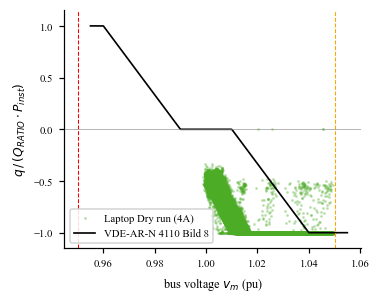

3,443,328 DER operating points plotted (deviation from the curve = DERDynamics PT1 filtering + coordination/clipping effects).


In [68]:
# =============================================================================
# CELL 8 — Q(V) OPERATING SCATTER
# =============================================================================
# Fields read: scenarios/volt_var_local.json -> timeseries[*].q_mvar_by_sgen
# (TimestepRecord.q_applied_mvar) and timeseries[*].vm_pu_by_bus
# (TimestepRecord.vm_pu), joined per DER through topology.json -> sgens[*].bus.
# Rated power per DER: topology.json sgens[*].sn_mva (fallback p_mw).


def read_qv_params(path) -> dict:
    """Parse U1_PU..U4_PU and Q_RATIO from volt_var_controller.py.
    Falls back to the VDE-AR-N 4110 Bild 8 defaults if the file is absent:
    hard-coded 0.96 / 0.99 / 1.01 / 1.04 pu, Q_RATIO = 0.25."""
    params = {"U1_PU": 0.96, "U2_PU": 0.99, "U3_PU": 1.01, "U4_PU": 1.04,
              "Q_RATIO": 0.25}
    p = Path(path) if path else None
    if p is None or not p.exists():
        print(f"volt_var_controller.py not found at '{path}' - "
              f"using hard-coded VDE-AR-N 4110 defaults {params}")
        return params
    text = p.read_text(encoding="utf-8", errors="replace")
    for name in params:
        m = re.search(rf"^\s*{name}\s*=\s*([0-9]*\.?[0-9]+)", text, re.MULTILINE)
        if m:
            params[name] = float(m.group(1))
    print(f"Q(V) parameters read from {p}: {params}")
    return params


def qv_theoretical(vm: np.ndarray, prm: dict) -> np.ndarray:
    """Dimensionless VDE-AR-N 4110 Bild 8 curve: q/q_max in [-1, +1].
    Mirrors QVCharacteristic.compute_setpoint() in volt_var_controller.py."""
    u1, u2, u3, u4 = prm["U1_PU"], prm["U2_PU"], prm["U3_PU"], prm["U4_PU"]
    q = np.zeros_like(vm)
    q[vm <= u1] = 1.0                                    # full injection
    ramp_lo = (vm > u1) & (vm < u2)
    q[ramp_lo] = (u2 - vm[ramp_lo]) / (u2 - u1)          # ramp -> 0
    ramp_hi = (vm > u3) & (vm < u4)
    q[ramp_hi] = -(vm[ramp_hi] - u3) / (u4 - u3)         # ramp -> absorb
    q[vm >= u4] = -1.0                                   # full absorption
    return q


_qv_payload = RUNS["A"]["scenarios"].get(SC_4A)
_qv_topo    = RUNS["A"]["topology"]

if _qv_payload is None or _qv_topo is None:
    print("Cell 8 skipped - volt_var_local.json or topology.json missing in RUN_A.")
else:
    prm = read_qv_params(VOLT_VAR_CONTROLLER_PATH)

    sgen_to_bus, sgen_qmax = {}, {}
    for s in _qv_topo.get("sgens", []):
        idx = int(s["index"])
        sgen_to_bus[idx] = int(s["bus"])
        p_ref = s.get("sn_mva") or s.get("p_mw") or 0.0   # sn_mva precedence,
        sgen_qmax[idx] = prm["Q_RATIO"] * abs(float(p_ref))  # as in VoltVarController

    vm_all, qn_all = [], []
    n_missing_maps = 0
    for rec in _qv_payload.get("timeseries", []):
        if not rec.get("converged", True):
            continue
        vm_map = rec.get("vm_pu_by_bus")
        q_map  = rec.get("q_mvar_by_sgen")
        if not vm_map or not q_map:
            n_missing_maps += 1
            continue
        for sgen_str, q in q_map.items():
            if q is None:
                continue
            sgen = int(sgen_str)
            bus  = sgen_to_bus.get(sgen)
            qmax = sgen_qmax.get(sgen, 0.0)
            if bus is None or qmax <= 0:
                continue
            vm = vm_map.get(str(bus))
            if vm is None:
                continue
            vm_all.append(float(vm))
            qn_all.append(float(q) / qmax)

    if not vm_all:
        print("Cell 8 skipped - q_mvar_by_sgen / vm_pu_by_bus not present "
              "in RUN_A volt_var_local timeseries.")
    else:
        if n_missing_maps:
            print(f"note: {n_missing_maps} timesteps had no per-element maps "
                  f"and were skipped.")
        vm_arr = np.asarray(vm_all)
        qn_arr = np.asarray(qn_all)

        # Cap the point count so the PDF stays paper-sized
        MAX_PTS = 200_000
        if len(vm_arr) > MAX_PTS:
            sel = np.random.default_rng(0).choice(len(vm_arr), MAX_PTS,
                                                  replace=False)
            vm_arr, qn_arr = vm_arr[sel], qn_arr[sel]
            print(f"note: scatter subsampled to {MAX_PTS:,} of "
                  f"{len(vm_all):,} operating points.")

        fig, ax = plt.subplots(figsize=(IEEE_1COL_W, 2.8))
        ax.scatter(vm_arr, qn_arr, s=1.0, alpha=0.25, color=COLOR_4A,
                   rasterized=True, label=f"{RUNS['A']['label']} (4A)")

        vgrid = np.linspace(min(vm_arr.min(), prm["U1_PU"]) - 0.005,
                            max(vm_arr.max(), prm["U4_PU"]) + 0.005, 400)
        ax.plot(vgrid, qv_theoretical(vgrid, prm), color="black", lw=1.1,
                label="VDE-AR-N 4110 Bild 8")

        ax.axvline(RUNS["A"]["v_min"], color="red",    ls="--", lw=0.7)
        ax.axvline(RUNS["A"]["v_max"], color="orange", ls="--", lw=0.7)
        ax.axhline(0, color="#888888", lw=0.4)
        ax.set_xlabel("bus voltage $v_m$ (pu)")
        ax.set_ylabel(r"$q \,/\, (Q_{RATIO} \cdot P_{inst})$")
        ax.set_ylim(-1.15, 1.15)
        ax.legend(loc="lower left")
        fig.tight_layout()
        save_fig(fig, "qv_scatter", formats=("pdf",))
        plt.show()
        print(f"{len(vm_all):,} DER operating points plotted "
              f"(deviation from the curve = DERDynamics PT1 filtering + "
              f"coordination/clipping effects).")

## Cell 9 — Export checklist and abstract template

The eight core paper outputs written by this notebook (all in `figures/`):

1. `comparison_table.csv` — Cell 3
2. `voltage_envelope.pdf` — Cell 4
3. `voltage_envelope.png` — Cell 4
4. `curtailment_monthly.pdf` — Cell 5
5. `timing_distribution.pdf` — Cell 6
6. `coordination_rate.pdf` — Cell 7
7. `qv_scatter.pdf` — Cell 8
8. `abstract_template.txt` — written by the next cell (the abstract below with the
   numbers filled in from this run pair)

The code cell below verifies each file exists on disk and prints the abstract template
with `[X]`, `[Y]`, `[Z]` and `[network]` auto-filled from the loaded data — `[CITE]` is
left for the student.

In [69]:
# =============================================================================
# CELL 9 — EXPORT CHECKLIST + ABSTRACT TEMPLATE
# =============================================================================
# Numbers pulled from: scenarios/*.json -> summary.curtailment_steps and
# summary.coordination_rate (ScenarioResult.summary_dict()), plus
# topology.json -> network_id.

def _summary_value(run_key, sid, field):
    payload = RUNS[run_key]["scenarios"].get(sid)
    if payload is None:
        return None
    return (payload.get("summary") or {}).get(field)


# ---- [X]: 4B curtailment reduction vs 4A, computed per run -------------------
def curtailment_reduction_pct(run_key):
    a = _summary_value(run_key, SC_4A, "curtailment_steps")
    b = _summary_value(run_key, SC_4B, "curtailment_steps")
    if a in (None, 0) or b is None:
        return None
    return 100.0 * (a - b) / a


X = {k: curtailment_reduction_pct(k) for k in ("A", "B")}
# [Y]/[Z]: coordination rates (Cell 7 already computed these; recompute-safe)
Y = coord_rates.get("B") if "coord_rates" in dir() else coordination_rate_pct("B")
Z = coord_rates.get("A") if "coord_rates" in dir() else coordination_rate_pct("A")


def _fmt(v, suffix=""):
    return f"{v:.1f}{suffix}" if v is not None else "[fill in]"


# NOTE: [Y] is filled with RUN_B and [Z] with RUN_A assuming the usual
# convention RUN_A = dry-run, RUN_B = HIL. Swap them if your runs are the
# other way round.
_x_txt = _fmt(X["B"] if X["B"] is not None else X["A"])
abstract = (
    f"This paper presents results from [{STUDENT_LABEL_A}] and "
    f"[{STUDENT_LABEL_B}] benchmarks on the HIL testbed. Scenario 4B reduced "
    f"curtailment by [{_x_txt}]% compared to 4A on "
    f"[{RUNS['A']['network_id']}]. The HIL coordination active rate was "
    f"[{_fmt(Y)}]% versus [{_fmt(Z)}]% in dry-run mode, consistent with the "
    f"hardware quantisation finding documented in [CITE]."
)

abstract_path = FIGURES_DIR / "abstract_template.txt"
abstract_path.write_text(abstract + "\n", encoding="utf-8")

# ---- checklist ---------------------------------------------------------------
CORE_OUTPUTS = [
    "comparison_table.csv",
    "voltage_envelope.pdf",
    "voltage_envelope.png",
    "curtailment_monthly.pdf",
    "timing_distribution.pdf",
    "coordination_rate.pdf",
    "qv_scatter.pdf",
    "abstract_template.txt",
]

print("Core output checklist")
print("-" * 46)
_all_ok = True
for fname in CORE_OUTPUTS:
    ok = (FIGURES_DIR / fname).exists()
    _all_ok &= ok
    print(f"  [{'x' if ok else ' '}] {fname}")
print("-" * 46)
print("ALL CORE OUTPUTS PRESENT" if _all_ok else
      "SOME OUTPUTS MISSING - check the warnings printed by the cells above "
      "(a missing scenario JSON in a run directory skips its figure).")

print("\nAbstract template (figures/abstract_template.txt):\n")
print(abstract)
for k in ("A", "B"):
    if X[k] is not None:
        print(f"\n  ({RUNS[k]['label']}: 4B curtailment reduction "
              f"vs 4A = {X[k]:.1f}%)")

Core output checklist
----------------------------------------------
  [x] comparison_table.csv
  [x] voltage_envelope.pdf
  [x] voltage_envelope.png
  [x] curtailment_monthly.pdf
  [x] timing_distribution.pdf
  [x] coordination_rate.pdf
  [x] qv_scatter.pdf
  [x] abstract_template.txt
----------------------------------------------
ALL CORE OUTPUTS PRESENT

Abstract template (figures/abstract_template.txt):

This paper presents results from [Laptop Dry run] and [RPi HIL Arduino] benchmarks on the HIL testbed. Scenario 4B reduced curtailment by [16.8]% compared to 4A on [1-MV-rural--2-sw]. The HIL coordination active rate was [100.0]% versus [9.5]% in dry-run mode, consistent with the hardware quantisation finding documented in [CITE].

  (Laptop Dry run: 4B curtailment reduction vs 4A = 16.8%)

  (RPi HIL Arduino: 4B curtailment reduction vs 4A = 16.8%)


---
# Extension figures (adapted from `plot_results.py`)

The four figures below are the remaining `plot_results.py` figures that (a) matter for
the paper and (b) are computable from the publisher JSON alone in a two-run comparison
context. They follow the same rules as Cells 4–8: matplotlib only, graceful skipping,
IEEE dimensions (full-width 7.16 in where a heatmap needs it), saved to `figures/`.

## Extension 1 — Voltage heatmap, timestep × bus (`fig05` equivalent)

`vm_pu_by_bus` per timestep for Scenario 4B, one panel per run, shared colour scale
centred on the planning band. Daily-max downsampling keeps the raster readable over an
annual run. This is the supervisors' "voltage violation heatmap" talking point. Saved
as `voltage_heatmap.png` (PNG only — a full-resolution heatmap PDF would be enormous).

C:\Users\Khuzaim\AppData\Local\Temp\ipykernel_22764\2175050934.py:54: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  return pd.to_datetime(vals, format="ISO8601", **kw)
C:\Users\Khuzaim\AppData\Local\Temp\ipykernel_22764\2175050934.py:54: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  return pd.to_datetime(vals, format="ISO8601", **kw)


saved: figures\voltage_heatmap.png


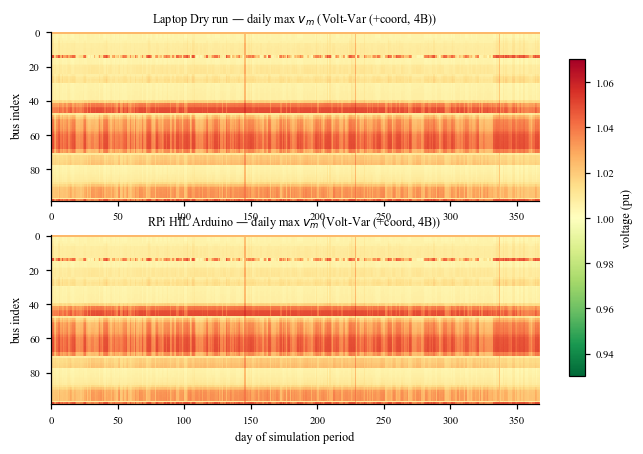

In [70]:
# =============================================================================
# EXTENSION 1 — VOLTAGE HEATMAP (timestep x bus), fig05 equivalent
# =============================================================================
# Fields read: scenarios/volt_var_coord.json -> timeseries[*].vm_pu_by_bus
# (TimestepRecord.vm_pu serialised as {bus_idx_str: vm_pu} per timestep).

_hm_runs = {k: RUNS[k]["scenarios"].get(SC_4B) for k in ("A", "B")}
_hm_runs = {k: v for k, v in _hm_runs.items()
            if v is not None and v.get("timeseries")}

if not _hm_runs:
    print("Extension 1 skipped - no volt_var_coord timeseries in either run.")
else:
    fig, axes = plt.subplots(len(_hm_runs), 1,
                             figsize=(IEEE_2COL_W, 2.2 * len(_hm_runs)),
                             squeeze=False)
    im = None
    for ax, (key, payload) in zip(axes[:, 0], _hm_runs.items()):
        ts = payload["timeseries"]
        bus_keys = sorted({k for rec in ts
                           for k in (rec.get("vm_pu_by_bus") or {})},
                          key=int)
        if not bus_keys:
            ax.text(0.5, 0.5, "no vm_pu_by_bus data", ha="center",
                    va="center", transform=ax.transAxes)
            continue
        mat = np.array([[(rec.get("vm_pu_by_bus") or {}).get(k, np.nan)
                         for k in bus_keys] for rec in ts], dtype=float)

        # Daily-max downsample (worst voltage per bus per day) - robust to
        # 10-min or 15-min resolution because the day grouping uses the
        # actual timestamps, not a hard-coded 144 steps/day.
        days = pd.DatetimeIndex(
            _parse_times([rec["timestamp"] for rec in ts])).normalize()
        day_frame = pd.DataFrame(mat, index=days)
        mat_ds = day_frame.groupby(level=0).max().to_numpy()

        v_lo, v_hi = RUNS[key]["v_min"], RUNS[key]["v_max"]
        im = ax.imshow(mat_ds.T, aspect="auto", interpolation="nearest",
                       cmap="RdYlGn_r", vmin=v_lo - 0.02, vmax=v_hi + 0.02,
                       origin="upper")
        ax.set_ylabel("bus index")
        ax.set_title(f"{RUNS[key]['label']} — daily max $v_m$ "
                     f"({scenario_label(SC_4B)})", fontsize=8)
    axes[-1, 0].set_xlabel("day of simulation period")
    if im is not None:
        fig.colorbar(im, ax=axes[:, 0], label="voltage (pu)", shrink=0.85)
    save_fig(fig, "voltage_heatmap", formats=("png",))
    plt.show()

## Extension 2 — Violation heatmap, day × scenario (`fig09` equivalent)

`violation_flag` per timestep, reduced to "any violation that day", for **every**
scenario found in each run — including custom controller-plugin scenarios, which appear
as extra rows automatically. One panel per run. Saved as `violation_heatmap.pdf`.

saved: figures\violation_heatmap.pdf


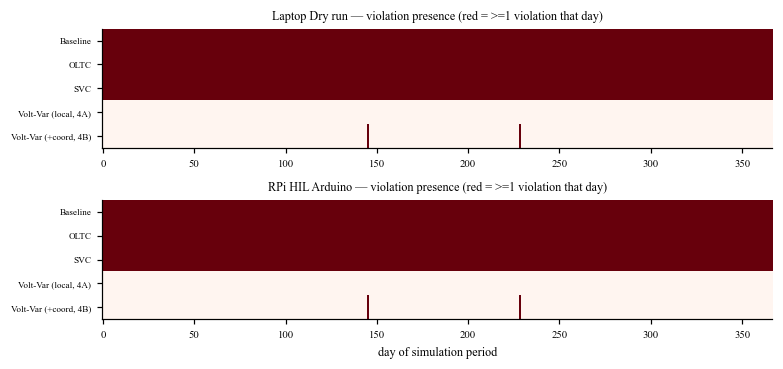

In [71]:
# =============================================================================
# EXTENSION 2 — VIOLATION HEATMAP (day x scenario), fig09 equivalent
# =============================================================================
# Fields read: scenarios/*.json -> timeseries[*].violation_flag (set True in
# build_scenario_payload() when any over/under-voltage bus or overloaded
# line/trafo list is non-empty for that TimestepRecord).

_panels = {}
for key in ("A", "B"):
    cols = {}
    for sid in sorted(RUNS[key]["ts"], key=scenario_sort_key):
        df = RUNS[key]["ts"][sid]
        if df is None:
            continue
        daily = (df["violation_flag"].fillna(False).astype(bool)
                 .groupby(df.index.normalize()).max())
        cols[sid] = daily
    if cols:
        _panels[key] = pd.DataFrame(cols)

if not _panels:
    print("Extension 2 skipped - no scenario timeseries in either run.")
else:
    fig, axes = plt.subplots(len(_panels), 1,
                             figsize=(IEEE_2COL_W, 1.0 + 1.2 * len(_panels)),
                             squeeze=False)
    for ax, (key, frame) in zip(axes[:, 0], _panels.items()):
        ax.imshow(frame.to_numpy(dtype=float).T, aspect="auto", cmap="Reds",
                  vmin=0, vmax=1, interpolation="nearest", origin="upper")
        ax.set_yticks(range(len(frame.columns)))
        ax.set_yticklabels([scenario_label(s) for s in frame.columns],
                           fontsize=6)
        ax.set_title(f"{RUNS[key]['label']} — violation presence "
                     f"(red = >=1 violation that day)", fontsize=8)
    axes[-1, 0].set_xlabel("day of simulation period")
    fig.tight_layout()
    save_fig(fig, "violation_heatmap", formats=("pdf",))
    plt.show()

## Extension 3 — Curtailed energy time series, 4A vs 4B (`fig13` equivalent)

Curtailed power per timestep = `der_gen_mw` (unconstrained profile target, from
`TimestepRecord.der_gen_mw`) − Σ `p_mw_by_sgen` (actually applied after the curtailment
loop, from `TimestepRecord.p_applied_mw`) — the exact definition used by `fig13` in
`plot_results.py`. Summed per day and integrated to **curtailed MWh** using the
timestep length inferred from the timestamps. This cell prints the curtailed-energy
totals and the 4A→4B energy reduction — the `[X]%` figure most papers quote in energy
terms rather than timestep counts. Saved as `curtailment_timeseries.pdf`.

saved: figures\curtailment_timeseries.pdf


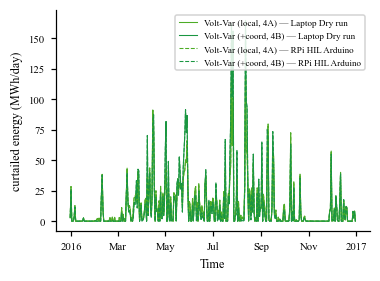

[Laptop Dry run] curtailed energy: 4A=4120.86 MWh, 4B=4464.62 MWh (4B reduction: -8.3%)
[RPi HIL Arduino] curtailed energy: 4A=4121.86 MWh, 4B=4463.60 MWh (4B reduction: -8.3%)


In [72]:
# =============================================================================
# EXTENSION 3 — CURTAILED ENERGY TIME SERIES (4A vs 4B), fig13 equivalent
# =============================================================================
# Fields read: scenarios/volt_var_*.json -> timeseries[*].der_gen_mw
# (profile target) and timeseries[*].p_mw_by_sgen (applied P, summed per
# timestep into p_applied_sum_mw during loading in Cell 2).

_style = {(SC_4A, "A"): dict(color=COLOR_4A, ls="-"),
          (SC_4B, "A"): dict(color=COLOR_4B, ls="-"),
          (SC_4A, "B"): dict(color=COLOR_4A, ls="--"),
          (SC_4B, "B"): dict(color=COLOR_4B, ls="--")}

fig, ax = plt.subplots(figsize=(IEEE_1COL_W, 2.6))
_plotted = False
_energy = {}

for (sid, key), st in _style.items():
    df = RUNS[key]["ts"].get(sid)
    if df is None:
        continue
    curt_mw = (pd.to_numeric(df["der_gen_mw"], errors="coerce")
               - pd.to_numeric(df["p_applied_sum_mw"], errors="coerce")
               ).clip(lower=0.0)
    if curt_mw.dropna().empty:
        continue
    dt_h = _step_hours(df)
    _energy[(sid, key)] = float(curt_mw.sum() * dt_h)      # MWh
    daily_mwh = (curt_mw * dt_h).groupby(df.index.normalize()).sum()
    ax.plot(daily_mwh.index, daily_mwh.values, lw=0.7,
            label=f"{scenario_label(sid)} — {RUNS[key]['label']}",
            rasterized=True, **st)
    _plotted = True

if not _plotted:
    plt.close(fig)
    print("Extension 3 skipped - no volt_var timeseries with P data.")
else:
    ax.set_ylabel("curtailed energy (MWh/day)")
    ax.set_xlabel("Time")
    locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.legend(fontsize=6)
    fig.tight_layout()
    save_fig(fig, "curtailment_timeseries", formats=("pdf",))
    plt.show()

    for key in ("A", "B"):
        e4a, e4b = _energy.get((SC_4A, key)), _energy.get((SC_4B, key))
        if e4a and e4b is not None:
            print(f"[{RUNS[key]['label']}] curtailed energy: "
                  f"4A={e4a:.2f} MWh, 4B={e4b:.2f} MWh "
                  f"(4B reduction: {100 * (e4a - e4b) / e4a:+.1f}%)")

## Extension 4 — Annual load + DER profile (`fig07` equivalent)

Loaded **lazily** from `profiles.json` (`publisher.build_profiles_payload()`), using the
hourly totals (`times_hourly`, `load_total_mw`, `pv_total_mw`, `wind_total_mw`) — 8,784
points instead of 35,136+, which is all a paper-sized figure can resolve anyway. Plotted
for RUN_A (falls back to RUN_B); the profile inputs are a property of the network/run
configuration, and this figure documents them for the paper's setup section. Saved as
`annual_profiles.pdf`.

C:\Users\Khuzaim\AppData\Local\Temp\ipykernel_22764\2175050934.py:54: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  return pd.to_datetime(vals, format="ISO8601", **kw)


saved: figures\annual_profiles.pdf


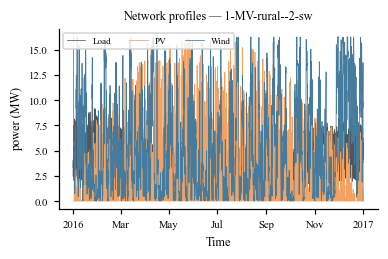

In [73]:
# =============================================================================
# EXTENSION 4 — ANNUAL LOAD + DER PROFILE, fig07 equivalent
# =============================================================================
# Fields read: profiles.json -> times_hourly, load_total_mw, pv_total_mw,
# wind_total_mw (hourly network totals from publisher.build_profiles_payload();
# loaded lazily here because profiles.json can be tens of MB).

_prof = None
_prof_key = None
for key in ("A", "B"):
    p = RUNS[key]["dir"] / "profiles.json"
    if p.exists():
        _prof = _load_json(p)
        _prof_key = key
        break

if not _prof or not _prof.get("times_hourly"):
    print("Extension 4 skipped - profiles.json (times_hourly) not found in "
          "either run directory.")
else:
    t_h = _parse_times(_prof["times_hourly"])

    fig, ax = plt.subplots(figsize=(IEEE_1COL_W, 2.4))
    for field, color, lbl in (("load_total_mw", "#555555", "Load"),
                              ("pv_total_mw",   "#f4a261", "PV"),
                              ("wind_total_mw", "#457b9d", "Wind")):
        vals = _prof.get(field)
        if vals:
            n = min(len(t_h), len(vals))
            ax.plot(t_h[:n], np.asarray(vals[:n], dtype=float), color=color,
                    lw=0.5, label=lbl, rasterized=True)

    ax.set_ylabel("power (MW)")
    ax.set_xlabel("Time")
    ax.set_title(f"Network profiles — {RUNS[_prof_key]['network_id']}",
                 fontsize=8)
    locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.legend(fontsize=6, ncol=3)
    fig.tight_layout()
    save_fig(fig, "annual_profiles", formats=("pdf",))
    plt.show()

---
## Complete output inventory

| # | File | Cell | Content |
|---|------|------|---------|
| 1 | `comparison_table.csv` | 3 | All `summary_dict()` scalars, one row per scenario per run (plugin scenarios included) |
| 2 | `voltage_envelope.pdf` | 4 | Annual max/min vm_pu, 4B, both runs |
| 3 | `voltage_envelope.png` | 4 | PNG twin of #2 |
| 4 | `curtailment_monthly.pdf` | 5 | Curtailed timesteps/month, 4A/4B × both runs |
| 5 | `timing_distribution.pdf` | 6 | t_total_ms histogram + HIL latency overlay, medians/p95 |
| 6 | `coordination_rate.pdf` | 7 | 4B coordination-active rate bars + quantisation note |
| 7 | `qv_scatter.pdf` | 8 | Normalised Q(V) operating points vs VDE-AR-N 4110 curve |
| 8 | `abstract_template.txt` | 9 | Abstract with auto-filled numbers |
| E1 | `voltage_heatmap.png` | Ext 1 | Day × bus voltage heatmap, 4B, both runs |
| E2 | `violation_heatmap.pdf` | Ext 2 | Day × scenario violation map, **all** scenarios |
| E3 | `curtailment_timeseries.pdf` | Ext 3 | Curtailed MWh/day, 4A vs 4B, both runs + energy totals |
| E4 | `annual_profiles.pdf` | Ext 4 | Load/PV/wind hourly profile documentation |
| E5 | `voltage_vs_feeder_dist.pdf` / `.png` | Ext 5 | Median vm_pu vs feeder distance per scenario, both runs overlaid |
| E6 | `benchmark_summary.pdf` / `.png` | Ext 6 | % improvement + absolute KPI bars, per run, from `summary_dict()` directly |

If a figure is missing, scroll up: the responsible cell printed exactly which scenario
JSON was absent from which run directory.

## Extension 5 — Voltage vs feeder distance (`fig06` equivalent)

Median bus voltage (with 5th-95th percentile band) binned against `topology.json ->
feeder_dist`, one line per scenario, overlaid across **both runs** via linestyle
(RUN_A solid, RUN_B dashed). This is a two-run adaptation of `plot_results.py`'s fig06
(originally single-run) -- overlaying both runs on one axis is more informative for a
paper than two separate PNGs, since it shows directly whether the spatial voltage-rise
pattern holds across dry-run/HIL or across two different override configurations, not
just within one run. Requires `feeder_dist` in `topology.json`; skips per-scenario if
absent (e.g. network plugins that don't populate it) rather than failing the whole cell.


saved: figures\voltage_vs_feeder_dist.pdf, figures\voltage_vs_feeder_dist.png


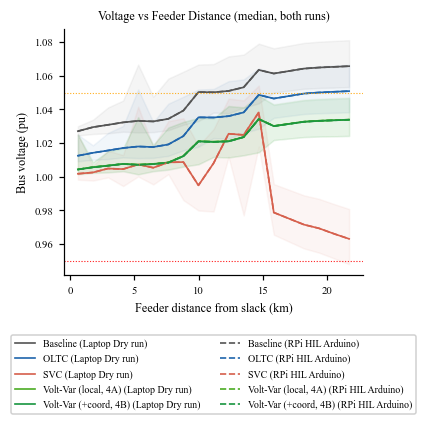

In [74]:
# =============================================================================
# EXTENSION 5 — VOLTAGE VS FEEDER DISTANCE, fig06 equivalent (two-run overlay)
# =============================================================================
# Fields read: topology.json -> feeder_dist (per-bus, single-run static data);
#              scenarios/<sid>.json -> timeseries[*].vm_pu_by_bus.
# Ported from plot_results.py's fig06_voltage_vs_feeder_dist(), which is
# single-run only (per COMPARE_RUNS_GUIDE.md's original exclusion rationale).
# Extended here to overlay RUN_A (solid) and RUN_B (dashed) on one axis --
# more informative for a paper than two separate single-run PNGs, since the
# question that matters is whether the spatial pattern holds across runs.

_LINESTYLE_BY_RUN = {"A": "-", "B": "--"}

def _feeder_dist_map(run_key):
    topo = RUNS[run_key]["topology"] or {}
    raw = topo.get("feeder_dist") or {}
    return {int(k): float(v) for k, v in raw.items() if v is not None}

_e5_any_data = False
fig, ax = plt.subplots(figsize=(IEEE_1COL_W, 4.0))

for run_key in ("A", "B"):
    dist_map = _feeder_dist_map(run_key)
    if not dist_map:
        print(f"Extension 5: run {run_key} ({RUNS[run_key]['label']}) has no "
              f"feeder_dist in topology.json -- skipping this run's lines.")
        continue

    scenario_ids = sorted(RUNS[run_key]["scenarios"].keys(), key=scenario_sort_key)
    for sid in scenario_ids:
        payload = RUNS[run_key]["scenarios"].get(sid)
        if payload is None or not payload.get("timeseries"):
            continue

        dists, vms = [], []
        for rec in payload["timeseries"]:
            if not rec.get("converged", True):
                continue
            vm_map = rec.get("vm_pu_by_bus") or {}
            for bus_str, vm in vm_map.items():
                bus_int = int(bus_str)
                if bus_int in dist_map and vm is not None:
                    dists.append(dist_map[bus_int])
                    vms.append(float(vm))

        if not dists:
            continue
        _e5_any_data = True

        dists = np.array(dists)
        vms   = np.array(vms)
        bins  = np.linspace(0, dists.max() + 0.01, 20)
        bin_idx = np.digitize(dists, bins)
        bin_mid, bin_med, bin_p5, bin_p95 = [], [], [], []
        for i in range(1, len(bins)):
            mask = bin_idx == i
            if mask.sum() < 2:
                continue
            v = vms[mask]
            bin_mid.append((bins[i - 1] + bins[i]) / 2)
            bin_med.append(np.median(v))
            bin_p5.append(np.percentile(v, 5))
            bin_p95.append(np.percentile(v, 95))

        color = SCENARIO_COLORS.get(sid, "#888888")
        ls    = _LINESTYLE_BY_RUN[run_key]
        label = f"{scenario_label(sid)} ({RUNS[run_key]['label']})"
        # Percentile band only for RUN_A to avoid a cluttered overlay --
        # RUN_B's band is still computed but shown as a thinner line only.
        if run_key == "A":
            ax.fill_between(bin_mid, bin_p5, bin_p95, color=color, alpha=0.06)
        ax.plot(bin_mid, bin_med, color=color, linestyle=ls, linewidth=1.1,
                label=label)

if not _e5_any_data:
    print("Extension 5 skipped - no feeder_dist + vm_pu_by_bus data in either run.")
    plt.close(fig)
else:
    # Voltage limit lines -- both runs' bands drawn if they differ (same
    # principle as Cell 4), so a custom-network run with a tighter/looser
    # band is represented correctly rather than assuming 0.95/1.05.
    for run_key in ("A", "B"):
        ax.axhline(RUNS[run_key]["v_min"], color="red", linestyle=":", lw=0.7, alpha=0.6)
        ax.axhline(RUNS[run_key]["v_max"], color="orange", linestyle=":", lw=0.7, alpha=0.6)

    ax.set_xlabel("Feeder distance from slack (km)")
    ax.set_ylabel("Bus voltage (pu)")
    ax.set_title("Voltage vs Feeder Distance (median, both runs)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=6.5,
              framealpha=0.9)
    fig.subplots_adjust(bottom=0.32)
    save_fig(fig, "voltage_vs_feeder_dist", formats=("pdf", "png"))
    plt.show()


## Extension 6 — Benchmark summary bars (`fig14` equivalent)

Grouped bar chart: (A) percent improvement over Baseline for metrics where a baseline
comparison is meaningful (`n_violation_steps`, `vdi`, `total_losses_mwh`), and (B)
absolute values for metrics with no baseline equivalent (`curtailed_energy_mwh`,
`reactive_energy_mvarh`). This is the clearest single "headline results" figure for the
paper. Unlike `plot_results.py`'s original (which reads an external benchmark CSV),
this version reads directly from each scenario's `summary` block already loaded by Cell
2 (`ScenarioResult.summary_dict()`, identical field set) -- no separate CSV file needed.
Produces one panel-pair **per run**, side by side, so RUN_A and RUN_B are directly
comparable rather than only the two-run difference being visible.


saved: figures\benchmark_summary.pdf, figures\benchmark_summary.png


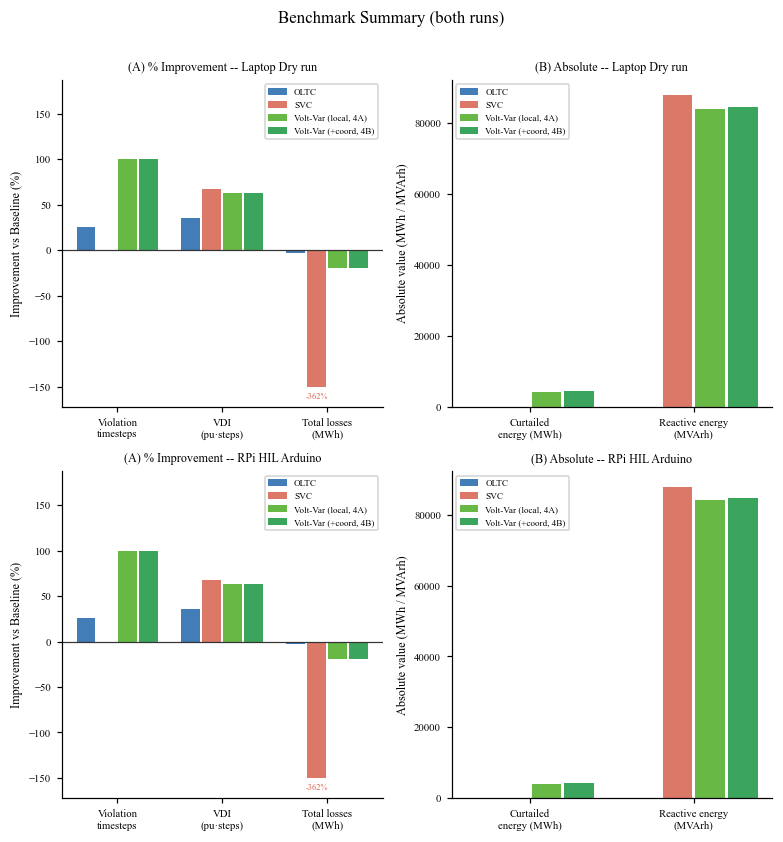

In [75]:
# =============================================================================
# EXTENSION 6 — BENCHMARK SUMMARY BARS, fig14 equivalent (per-run, side by side)
# =============================================================================
# Fields read: scenarios/<sid>.json -> summary (ScenarioResult.summary_dict()).
# Ported from plot_results.py's fig14_benchmark_summary(), which reads an
# external benchmark CSV; this version reads the same fields directly from
# the summary blocks Cell 2 already loaded, so no CSV file is required.

_PCT_METRICS = [
    ("n_violation_steps", "Violation\ntimesteps"),
    ("vdi",               "VDI\n(pu\u00b7steps)"),
    ("total_losses_mwh",  "Total losses\n(MWh)"),
]
_ABS_METRICS = [
    ("curtailed_energy_mwh",  "Curtailed\nenergy (MWh)"),
    ("reactive_energy_mvarh", "Reactive energy\n(MVArh)"),
]
_Y_CAP = 150.0


def _run_summary_rows(run_key):
    """{scenario_id: summary_dict} for all non-baseline scenarios with a summary."""
    out = {}
    for sid, payload in RUNS[run_key]["scenarios"].items():
        if sid == "baseline" or payload is None:
            continue
        summ = payload.get("summary")
        if summ:
            out[sid] = summ
    return out


def _plot_benchmark_summary(ax_pct, ax_abs, run_key):
    base_payload = RUNS[run_key]["scenarios"].get("baseline")
    base_summary = (base_payload or {}).get("summary") or {}
    rows = _run_summary_rows(run_key)
    if not rows:
        ax_pct.set_visible(False)
        ax_abs.set_visible(False)
        print(f"Extension 6: run {run_key} ({RUNS[run_key]['label']}) has no "
              f"non-baseline scenario summaries -- skipping this run's panels.")
        return

    ordered_sids = sorted(rows.keys(), key=scenario_sort_key)
    n_scen = len(ordered_sids)

    pct_avail = [(c, l) for c, l in _PCT_METRICS if base_summary.get(c) is not None]
    abs_avail = [(c, l) for c, l in _ABS_METRICS
                 if any(rows[s].get(c) is not None for s in ordered_sids)]

    # ---- Panel A: % improvement over baseline ----
    if pct_avail:
        x_pct  = np.arange(len(pct_avail))
        width  = 0.8 / n_scen
        for i, sid in enumerate(ordered_sids):
            color = SCENARIO_COLORS.get(sid, f"C{i}")
            label = scenario_label(sid)
            vals = []
            for col, _ in pct_avail:
                v, base = rows[sid].get(col), base_summary.get(col)
                if v is not None and base not in (None, 0):
                    vals.append((float(base) - float(v)) / abs(float(base)) * 100)
                else:
                    vals.append(0.0)
            offset = (i - n_scen / 2 + 0.5) * width
            for xi, val in zip(x_pct + offset, vals):
                clipped = max(-_Y_CAP, min(_Y_CAP, val))
                ax_pct.bar(xi, clipped, width * 0.9, color=color, alpha=0.85,
                           label=label if xi == (x_pct + offset)[0] else "_nolegend_")
                if abs(val) > _Y_CAP:
                    sign = "+" if val > 0 else ""
                    ax_pct.annotate(f"{sign}{val:.0f}%",
                                    xy=(xi, _Y_CAP * np.sign(val)),
                                    xytext=(0, 4 * int(np.sign(val))),
                                    textcoords="offset points", ha="center",
                                    va="bottom" if val > 0 else "top",
                                    fontsize=5.5, color=color)
        ax_pct.axhline(0, color="#333333", lw=0.8)
        ax_pct.set_ylim(-_Y_CAP * 1.15, _Y_CAP * 1.25)
        ax_pct.set_xticks(x_pct)
        ax_pct.set_xticklabels([l for _, l in pct_avail], fontsize=7)
        ax_pct.set_ylabel("Improvement vs Baseline (%)")
        ax_pct.set_title(f"(A) % Improvement -- {RUNS[run_key]['label']}", fontsize=8)
        ax_pct.legend(fontsize=6)
    else:
        ax_pct.set_visible(False)

    # ---- Panel B: absolute values (no baseline defined) ----
    if abs_avail:
        x_abs = np.arange(len(abs_avail))
        width = 0.8 / n_scen
        for i, sid in enumerate(ordered_sids):
            color = SCENARIO_COLORS.get(sid, f"C{i}")
            label = scenario_label(sid)
            vals = [float(rows[sid].get(col, 0) or 0) for col, _ in abs_avail]
            offset = (i - n_scen / 2 + 0.5) * width
            ax_abs.bar(x_abs + offset, vals, width * 0.9, color=color,
                       label=label, alpha=0.85)
        ax_abs.set_xticks(x_abs)
        ax_abs.set_xticklabels([l for _, l in abs_avail], fontsize=7)
        ax_abs.set_ylabel("Absolute value (MWh / MVArh)")
        ax_abs.set_title(f"(B) Absolute -- {RUNS[run_key]['label']}", fontsize=8)
        ax_abs.legend(fontsize=6)
    else:
        ax_abs.set_visible(False)


fig, axes = plt.subplots(2, 2, figsize=(IEEE_2COL_W, 7.5))
_plot_benchmark_summary(axes[0, 0], axes[0, 1], "A")
_plot_benchmark_summary(axes[1, 0], axes[1, 1], "B")
fig.suptitle("Benchmark Summary (both runs)", fontsize=11, y=1.01)
fig.tight_layout()
save_fig(fig, "benchmark_summary", formats=("pdf", "png"))
plt.show()
